# 04 — Oil Sensitivity & Multi-Factor Regression

Single-factor oil beta estimation, rolling betas, and 6-factor regression model.

**Model:** R_stock = a + b1*R_WTI + b2*dVIX + b3*d2s10s + b4*dDXY + b5*dBkev + b6*dOVX

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from energy_workbook.config import ALL_TICKERS, EQUITY_TICKERS, RF_RATE

VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'legend.fontsize': 9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666']

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)
MASTER = D['master']; LOG_RET = D['log_returns']; DIFFS = D['diffs']
print('Data loaded')

Data loaded


## 4.1 Single-Factor Oil Beta

In [2]:
wti_ret = LOG_RET.get('WTI', pd.Series(dtype=float)).dropna()

oil_betas = {}
for t in EQUITY_TICKERS:
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    common = r.index.intersection(wti_ret.index)
    if len(common) > 60:
        x, y = wti_ret[common].values, r[common].values
        X = np.column_stack([np.ones(len(x)), x])
        betas = np.linalg.lstsq(X, y, rcond=None)[0]
        resid = y - X @ betas
        sst = np.sum((y - y.mean())**2)
        sse = np.sum(resid**2)
        oil_betas[t] = {'alpha': float(betas[0]), 'beta': float(betas[1]),
                        'r2': float(1 - sse/sst) if sst > 0 else 0}

beta_df = pd.DataFrame(oil_betas).T
beta_df.to_csv(os.path.join(DATA, 'oil_betas.csv'))
beta_df.sort_values('beta', ascending=False)

,alpha,beta,r2
VG,-0.001939,0.858536,0.137716
OXY,-0.000198,0.491953,0.204089
COP,0.000324,0.355772,0.218241
ET,0.000373,0.275603,0.167383
XOM,0.000520,0.256521,0.194625
CVX,0.000382,0.232080,0.147602
LNG,0.000764,0.160898,0.064948
STNG,0.000700,0.143513,0.019167
FRO,0.001170,0.115766,0.013231


In [ ]:
# Oil Beta Ranking Chart
sb = sorted(oil_betas.items(), key=lambda x: x[1]['beta'], reverse=True)
fig, ax = plt.subplots(figsize=(9, 5))
ts = [t for t, _ in sb]; bv = [b['beta'] for _, b in sb]
cs = ['#C00000' if b > 0.5 else '#E06C00' if b > 0.2 else '#0070C0' if b > 0 else '#666' for b in bv]
bars = ax.barh(ts[::-1], bv[::-1], color=cs[::-1], edgecolor='white', height=0.6)
for bar, val in zip(bars, bv[::-1]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Oil Beta')
ax.set_title('Oil Price Sensitivity by Security', fontweight='bold')
ax.axvline(0, color='#333', linewidth=0.5)
fig.tight_layout()
savefig(fig, '02_oil_beta_ranking.png')
plt.show()

## 4.2 Rolling Oil Beta (252-day window)

In [3]:
window = 252
rolling_betas = {}
for t in EQUITY_TICKERS:
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    common = r.index.intersection(wti_ret.index)
    if len(common) > window:
        rb = pd.Series(np.nan, index=common)
        for i in range(window, len(common)):
            x = wti_ret[common[i-window:i]].values
            y = r[common[i-window:i]].values
            X = np.column_stack([np.ones(len(x)), x])
            try:
                b = np.linalg.lstsq(X, y, rcond=None)[0]
                rb.iloc[i] = b[1]
            except:
                pass
        rolling_betas[t] = rb.dropna()

print(f'Computed rolling betas for {len(rolling_betas)} tickers')

Computed rolling betas for 9 tickers


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
for i, (t, rb) in enumerate(rolling_betas.items()):
    ax.plot(rb.index, rb.values, label=t, color=MC_COLORS[i % len(MC_COLORS)],
            linewidth=1.5 if t in ['COP','OXY','FRO','BIL'] else 0.8,
            alpha=1.0 if t in ['COP','OXY','FRO','BIL'] else 0.5)

ax.axhline(0, color='#333', linewidth=0.8, linestyle='--')
ax.set_title('Rolling 252-Day Oil Beta', fontweight='bold')
ax.set_ylabel('Beta to WTI')
ax.legend(ncol=5, fontsize=8, loc='upper left')
fig.tight_layout()
savefig(fig, '18_rolling_oil_beta.png')
plt.show()

## 4.3 Multi-Factor Regression (6 factors)

In [4]:
factor_names = ['R_WTI', 'dVIX', 'dSpread_2s10s', 'dDXY_log', 'dT10YIE', 'dOVX']
factors = pd.DataFrame(index=MASTER.index)
factor_map = {
    'R_WTI': ('log_returns', 'WTI'),
    'dVIX': ('diffs', 'dVIX'),
    'dSpread_2s10s': ('diffs', 'dSpread_2s10s'),
    'dDXY_log': ('diffs', 'dDXY_log'),
    'dT10YIE': ('diffs', 'dT10YIE'),
    'dOVX': ('diffs', 'dOVX'),
}
for fn, (src, col) in factor_map.items():
    s = D[src] if src in D else pd.DataFrame()
    if col in s.columns:
        factors[fn] = s[col]
factors = factors.dropna()

reg_results = {}
for t in EQUITY_TICKERS:
    y = LOG_RET.get(t, pd.Series(dtype=float))
    common = factors.index.intersection(y.dropna().index)
    if len(common) < 60:
        continue
    Y = y[common].values
    X = np.column_stack([np.ones(len(common)), factors.loc[common].values])
    try:
        betas = np.linalg.lstsq(X, Y, rcond=None)[0]
        resid = Y - X @ betas
        sst = np.sum((Y - Y.mean())**2)
        reg_results[t] = {
            'betas': dict(zip(['alpha'] + factor_names, betas)),
            'r2': float(1 - np.sum(resid**2) / sst) if sst > 0 else 0,
        }
    except:
        pass

# Display coefficients
coef_df = pd.DataFrame({t: v['betas'] for t, v in reg_results.items()}).T
coef_df['R2'] = [reg_results[t]['r2'] for t in coef_df.index]
coef_df.round(4)

,alpha,R_WTI,dVIX,dSpread_2s10s,dDXY_log,dT10YIE,dOVX,R2
XOM,0.0006,0.2095,-0.0026,0.0258,-0.6720,0.1082,0.0002,0.3567
CVX,0.0004,0.1624,-0.0030,0.0063,-0.7159,0.1388,0.0000,0.3566
COP,0.0004,0.2847,-0.0040,0.0097,-0.6747,0.1527,0.0002,0.4061
OXY,-0.0001,0.3793,-0.0041,0.0492,-0.9469,0.2207,-0.0001,0.3427
LNG,0.0008,0.1086,-0.0025,-0.0197,-0.8954,0.1048,0.0000,0.2012
VG,-0.0014,0.7403,-0.0068,0.0347,-0.3928,0.2251,0.0007,0.2166
FRO,0.0012,0.0496,-0.0029,-0.0139,-0.8360,0.1005,-0.0001,0.0758
STNG,0.0007,0.0674,-0.0040,0.0267,-0.1506,0.0652,-0.0002,0.0949
ET,0.0004,0.1803,-0.0034,0.0102,-0.8882,0.0859,-0.0005,0.3635


## 4.4 R-squared: Oil-Only vs Multi-Factor

  saved 25_factor_r2_comparison.png


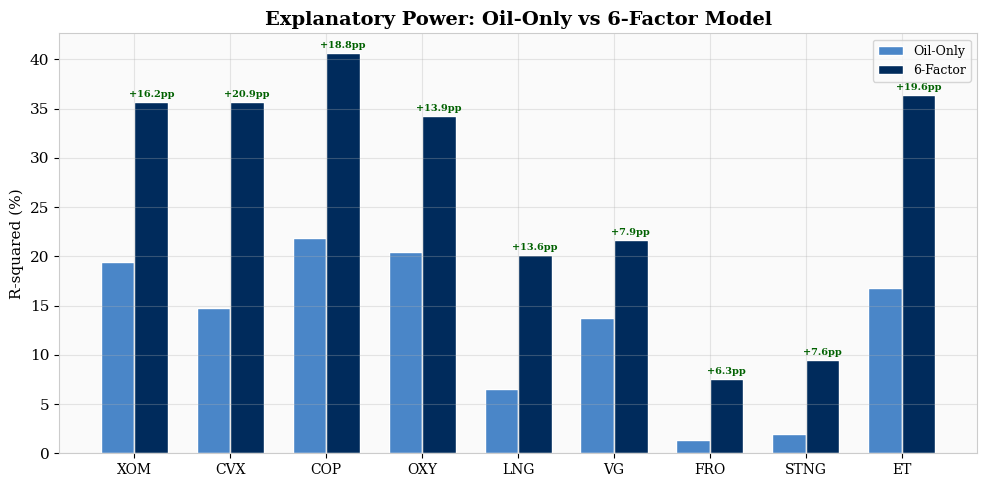

In [5]:
r2_data = {t: {'Oil-Only R2': oil_betas.get(t, {}).get('r2', 0),
               'Multi-Factor R2': reg_results.get(t, {}).get('r2', 0)}
           for t in EQUITY_TICKERS if t in oil_betas and t in reg_results}

r2_df = pd.DataFrame(r2_data).T
r2_df.to_csv(os.path.join(DATA, 'factor_r2_comparison.csv'))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(r2_df))
w = 0.35
ax.bar(x - w/2, r2_df['Oil-Only R2'] * 100, w, label='Oil-Only', color='#4A86C8', edgecolor='white')
ax.bar(x + w/2, r2_df['Multi-Factor R2'] * 100, w, label='6-Factor', color='#002B5C', edgecolor='white')

for i, t in enumerate(r2_df.index):
    gain = (r2_df.loc[t, 'Multi-Factor R2'] - r2_df.loc[t, 'Oil-Only R2']) * 100
    ax.text(i + w/2, r2_df.loc[t, 'Multi-Factor R2'] * 100 + 0.5,
            f'+{gain:.1f}pp', ha='center', fontsize=7, color='#006100', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(r2_df.index, fontsize=10)
ax.set_ylabel('R-squared (%)')
ax.set_title('Explanatory Power: Oil-Only vs 6-Factor Model', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
savefig(fig, '25_factor_r2_comparison.png')
plt.show()

## 4.5 Rolling Correlation with WTI

  saved 10_rolling_corr_wti.png


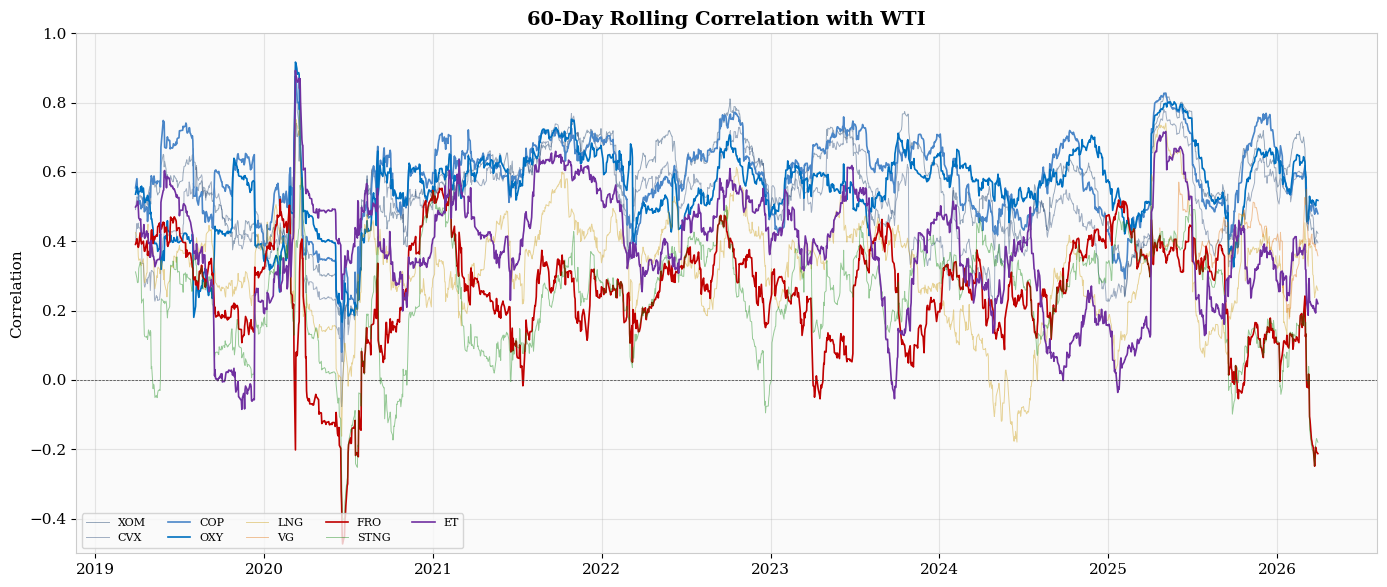

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
window = 60
for i, t in enumerate(EQUITY_TICKERS):
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    common = r.index.intersection(wti_ret.index)
    if len(common) > window:
        rc = r[common].rolling(window).corr(wti_ret[common]).dropna()
        ax.plot(rc.index, rc.values, label=t, color=MC_COLORS[i % len(MC_COLORS)],
                linewidth=1.2 if t in ['COP','OXY','FRO','ET'] else 0.7,
                alpha=1.0 if t in ['COP','OXY','FRO','ET'] else 0.4)

ax.axhline(0, color='#333', linewidth=0.5, linestyle='--')
ax.set_title('60-Day Rolling Correlation with WTI', fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_ylim(-0.5, 1.0)
ax.legend(ncol=5, fontsize=8, loc='lower left')
fig.tight_layout()
savefig(fig, '10_rolling_corr_wti.png')
plt.show()